# Results Dashboard — Fraud Detection ML System

This notebook provides a visual summary of the fraud detection system's results across all phases, from model discrimination through cost-sensitive evaluation to deployment simulation.

**How to read this notebook:**
- Each section stands alone and can be read independently.
- All results are computed on the **temporal validation set** (most recent 20% of transactions) — no data leakage.
- Key numbers are annotated directly on the charts.

**Prerequisites:** run `scripts/train_model.py` at least once to generate `artifacts/models/gb_v1_*.pkl`.

In [1]:
import sys
import json
import joblib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, roc_auc_score,
)

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import load_full_training_dataset
from src.data.split import temporal_train_val_split
from src.features.pipeline import build_features
from src.utils.config import DATA_PATH, MODELS_DIR
from src.models.metrics import expected_loss, approve_all_baseline_loss, threshold_sweep

# ── Visual style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#2e3248",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#2e3248",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
    "axes.titleweight": "bold",
})
ACCENT   = "#58a6ff"
FRAUD    = "#f85149"
LEGIT    = "#3fb950"
NEUTRAL  = "#d29922"
MUTED    = "#8b949e"

print("Setup complete.")

Setup complete.


In [2]:
# ── Load model and metadata ──────────────────────────────────────────────────
model_files = sorted(MODELS_DIR.glob("gb_v1_*.pkl"))
if not model_files:
    raise FileNotFoundError("No GB model artifact found. Run scripts/train_model.py first.")

model_path = model_files[-1]
meta_path  = model_path.with_name(model_path.stem + "_meta.json")
model      = joblib.load(model_path)
meta       = json.loads(meta_path.read_text(encoding="utf-8"))
metrics    = meta["metrics"]

THRESHOLD       = metrics["best_threshold"]
C_FP            = 5.0
SPLIT_QUANTILE  = 0.8

print(f"Model:      {model_path.name}")
print(f"Threshold:  {THRESHOLD}")
print(f"ROC-AUC:    {metrics['roc_auc']:.4f}")
print(f"PR-AUC:     {metrics['pr_auc']:.4f}")
print(f"EML reduc.: {metrics['expected_loss_reduction']:,.0f}  ({metrics['expected_loss_reduction']/metrics['baseline_loss']*100:.1f}% vs baseline)")

Model:      gb_v1_20260312_182000.pkl
Threshold:  0.02
ROC-AUC:    0.8614
PR-AUC:     0.4086
EML reduc.: 357,989  (58.7% vs baseline)


In [3]:
# ── Load data and build validation set ──────────────────────────────────────
print("Loading dataset (this may take a minute)...")
df = load_full_training_dataset(DATA_PATH)

_, X_val_raw, _, y_val, val_amount = temporal_train_val_split(
    df,
    split_quantile=SPLIT_QUANTILE,
    target_col="isFraud",
    time_col="TransactionDT",
    amount_col="TransactionAmt",
)

X_val, feature_list = build_features(X_val_raw, feature_set="v1")
y_val_arr    = y_val.values
val_proba    = model.predict_proba(X_val)[:, 1]
val_pred     = (val_proba >= THRESHOLD).astype(int)

fraud_rate   = y_val_arr.mean()
n_val        = len(y_val_arr)
n_fraud      = y_val_arr.sum()

print(f"Validation set: {n_val:,} transactions  |  Fraud: {n_fraud:,}  ({fraud_rate*100:.1f}%)")

Loading dataset (this may take a minute)...
Validation set: 118,108 transactions  |  Fraud: 4,064  (3.4%)


---
## Section 1 — Model Discrimination

The ROC curve shows how well the model separates fraud from legitimate transactions across all possible thresholds. A perfect model has AUC=1.0; a random model has AUC=0.5.

The PR curve focuses on precision–recall trade-offs for the rare positive class (fraud). In highly imbalanced datasets, PR-AUC is more informative than ROC-AUC because it is not dominated by the large number of true negatives.

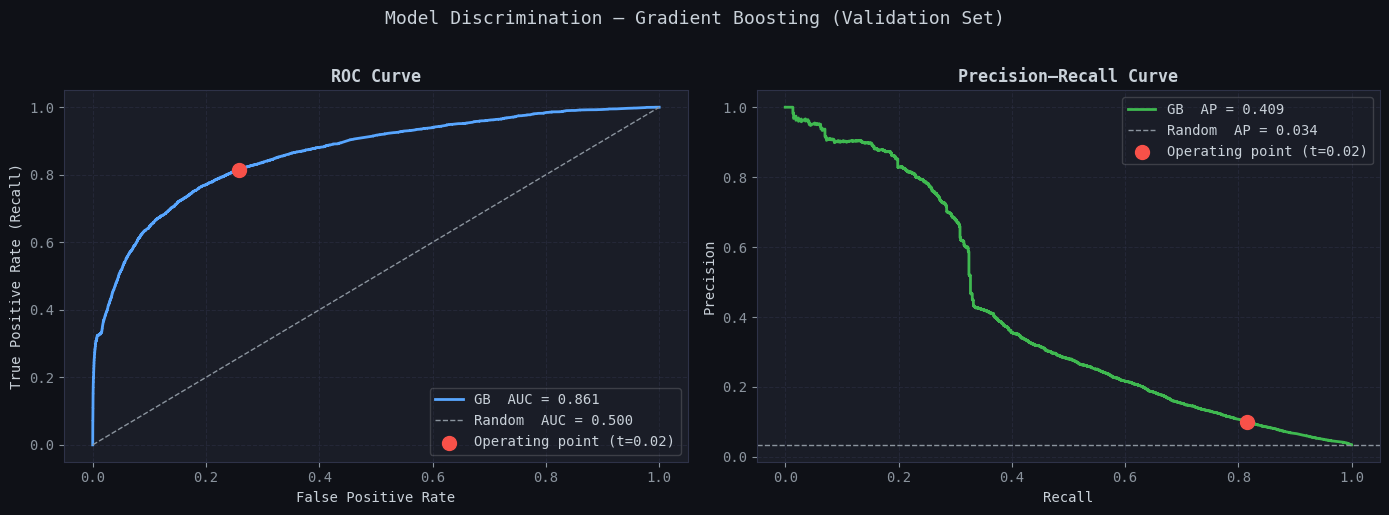

ROC-AUC: 0.8614  |  PR-AUC: 0.4086
Operating point — Recall: 0.815  Precision: 0.101  FPR: 0.259


In [4]:
fpr_arr, tpr_arr, _   = roc_curve(y_val_arr, val_proba)
roc_auc_val           = auc(fpr_arr, tpr_arr)
prec_arr, rec_arr, _  = precision_recall_curve(y_val_arr, val_proba)
pr_auc_val            = average_precision_score(y_val_arr, val_proba)

# Operating point
op_fpr = val_pred[y_val_arr == 0].mean()
op_tpr = val_pred[y_val_arr == 1].mean()
op_prec = val_pred[y_val_arr == 1].sum() / val_pred.sum() if val_pred.sum() > 0 else 0
op_rec  = op_tpr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Discrimination — Gradient Boosting (Validation Set)", fontsize=13, y=1.02)

# ROC
ax = axes[0]
ax.plot(fpr_arr, tpr_arr, color=ACCENT, lw=2, label=f"GB  AUC = {roc_auc_val:.3f}")
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--", label="Random  AUC = 0.500")
ax.scatter([op_fpr], [op_tpr], color=FRAUD, s=100, zorder=5, label=f"Operating point (t={THRESHOLD})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve")
ax.legend(framealpha=0.2)
ax.grid(True)

# PR
ax = axes[1]
ax.plot(rec_arr, prec_arr, color=LEGIT, lw=2, label=f"GB  AP = {pr_auc_val:.3f}")
ax.axhline(fraud_rate, color=MUTED, lw=1, ls="--", label=f"Random  AP = {fraud_rate:.3f}")
ax.scatter([op_rec], [op_prec], color=FRAUD, s=100, zorder=5, label=f"Operating point (t={THRESHOLD})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curve")
ax.legend(framealpha=0.2)
ax.grid(True)

plt.tight_layout()
plt.show()
print(f"ROC-AUC: {roc_auc_val:.4f}  |  PR-AUC: {pr_auc_val:.4f}")
print(f"Operating point — Recall: {op_tpr:.3f}  Precision: {op_prec:.3f}  FPR: {op_fpr:.3f}")

---
## Section 2 — Cost-Sensitive Evaluation

The Expected Monetary Loss (EML) curve shows the total financial cost — missed fraud losses plus operational review costs — at every possible threshold. The optimal threshold is the lowest point on this curve.

The horizontal dashed line is the **approve-all baseline**: the cost of taking no action. Any point below this line represents a financial improvement over the do-nothing strategy.

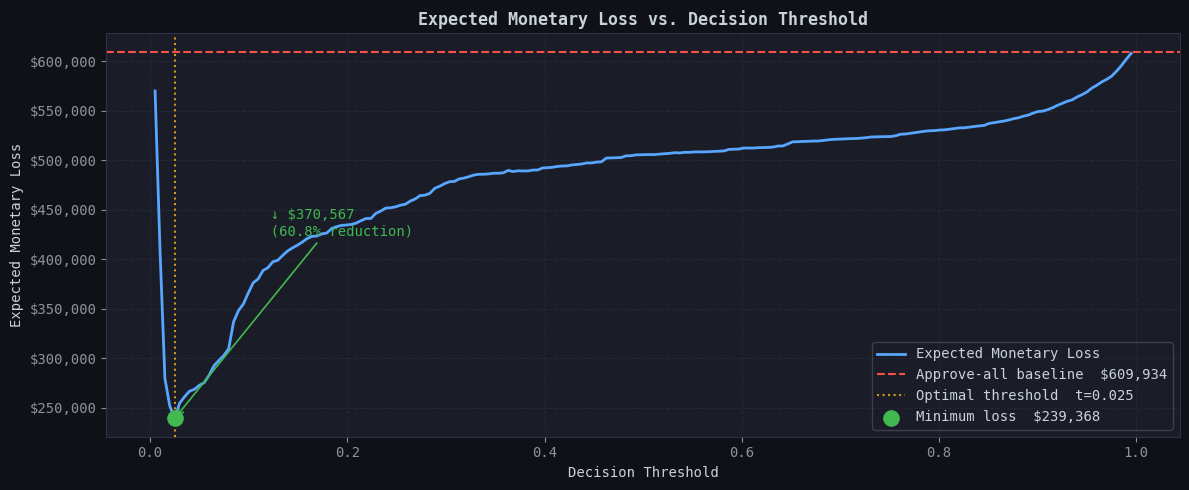

In [5]:
thresholds_arr       = np.linspace(0.005, 0.995, 200)
baseline_loss_val    = approve_all_baseline_loss(y_val_arr, val_amount.values)
losses               = [expected_loss(y_val_arr, val_proba, val_amount.values, C_FP, t) for t in thresholds_arr]
best_idx             = np.argmin(losses)
best_t_plot          = thresholds_arr[best_idx]
best_loss_plot       = losses[best_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds_arr, losses, color=ACCENT, lw=2, label="Expected Monetary Loss")
ax.axhline(baseline_loss_val, color=FRAUD, lw=1.5, ls="--",
           label=f"Approve-all baseline  ${baseline_loss_val:,.0f}")
ax.axvline(best_t_plot, color=NEUTRAL, lw=1.5, ls=":",
           label=f"Optimal threshold  t={best_t_plot:.3f}")
ax.scatter([best_t_plot], [best_loss_plot], color=LEGIT, s=120, zorder=5,
           label=f"Minimum loss  ${best_loss_plot:,.0f}")

reduction = baseline_loss_val - best_loss_plot
ax.annotate(
    f"  ↓ ${reduction:,.0f}\n  ({reduction/baseline_loss_val*100:.1f}% reduction)",
    xy=(best_t_plot, best_loss_plot),
    xytext=(best_t_plot + 0.08, (baseline_loss_val + best_loss_plot) / 2),
    color=LEGIT, fontsize=10,
    arrowprops=dict(arrowstyle="->", color=LEGIT, lw=1.2),
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Expected Monetary Loss")
ax.set_title("Expected Monetary Loss vs. Decision Threshold")
ax.legend(framealpha=0.2)
ax.grid(True)
plt.tight_layout()
plt.show()

---
## Section 3 — Operating Point Analysis

The confusion matrix shows exactly what happens at the chosen operating threshold (t=0.02).

- **True Negatives (top-left):** legitimate transactions correctly approved.
- **False Positives (top-right):** legitimate transactions incorrectly flagged — the cost of customer friction.
- **False Negatives (bottom-left):** fraud that slipped through — the primary loss driver.
- **True Positives (bottom-right):** fraud correctly intercepted.

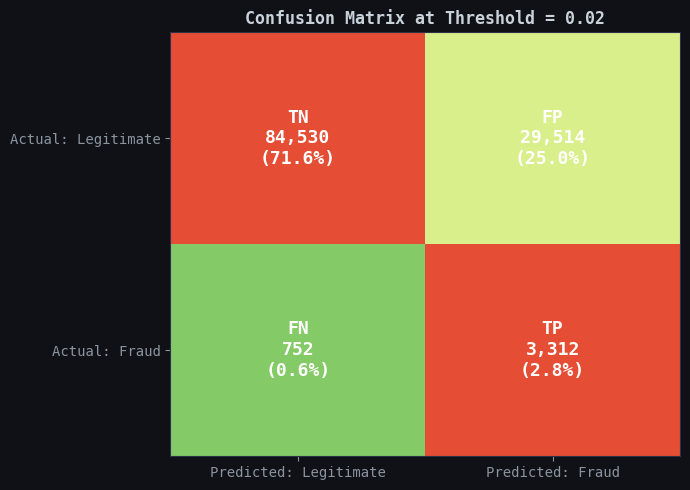

Recall (fraud capture rate): 81.5%  — 3,312 of 4,064 fraud cases intercepted
Precision (alert quality):   10.1%  — 3,312 real fraud per 32,826 alerts
False positive rate:         25.9%  — 29,514 of 114,044 legitimate transactions flagged


In [6]:
cm = confusion_matrix(y_val_arr, val_pred)
tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp

labels = np.array([
    [f"TN\n{tn:,}\n({tn/total*100:.1f}%)",  f"FP\n{fp:,}\n({fp/total*100:.1f}%)"],
    [f"FN\n{fn:,}\n({fn/total*100:.1f}%)",  f"TP\n{tp:,}\n({tp/total*100:.1f}%)"]
])

colors = np.array([
    [0.15, 0.60],
    [0.75, 0.15],
])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(colors, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i, j], ha="center", va="center",
                fontsize=13, color="white", fontweight="bold")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted: Legitimate", "Predicted: Fraud"], fontsize=10)
ax.set_yticklabels(["Actual: Legitimate", "Actual: Fraud"], fontsize=10)
ax.set_title(f"Confusion Matrix at Threshold = {THRESHOLD}", fontsize=12)

plt.tight_layout()
plt.show()

recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
print(f"Recall (fraud capture rate): {recall:.1%}  — {tp:,} of {tp+fn:,} fraud cases intercepted")
print(f"Precision (alert quality):   {precision:.1%}  — {tp:,} real fraud per {tp+fp:,} alerts")
print(f"False positive rate:         {fp/(fp+tn):.1%}  — {fp:,} of {fp+tn:,} legitimate transactions flagged")

---
## Section 4 — Feature Importance

The chart shows the top 20 features by importance score from the Gradient Boosting model. Feature importance in GB is computed as the total reduction in node impurity (Gini/entropy) contributed by each feature across all trees.

The `V` features are anonymized behavioral features engineered by Vesta (the payment provider). The `C` features are count-based behavioral aggregates. `TransactionAmt` and `card` features are transaction properties.

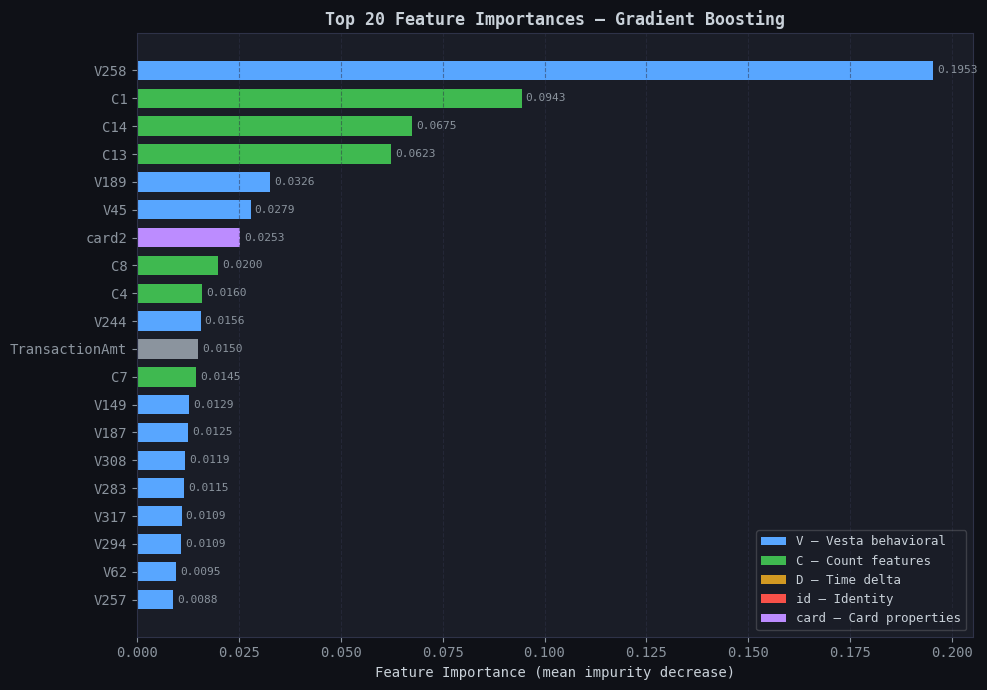

In [7]:
importances = model.feature_importances_
feat_imp_df = (
    pd.DataFrame({"feature": feature_list, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
    .iloc[::-1]
)

def feature_color(name):
    if name.startswith("V"):        return ACCENT
    if name.startswith("C"):        return LEGIT
    if name.startswith("D"):        return NEUTRAL
    if name.startswith("id_"):      return FRAUD
    if name.startswith("card"):     return "#bc8cff"
    return MUTED

bar_colors = [feature_color(f) for f in feat_imp_df["feature"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_imp_df["feature"], feat_imp_df["importance"],
               color=bar_colors, edgecolor="none", height=0.7)

for bar, val in zip(bars, feat_imp_df["importance"]):
    ax.text(val + feat_imp_df["importance"].max() * 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8, color=MUTED)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ACCENT,    label="V — Vesta behavioral"),
    Patch(facecolor=LEGIT,     label="C — Count features"),
    Patch(facecolor=NEUTRAL,   label="D — Time delta"),
    Patch(facecolor=FRAUD,     label="id — Identity"),
    Patch(facecolor="#bc8cff", label="card — Card properties"),
]
ax.legend(handles=legend_elements, loc="lower right", framealpha=0.2, fontsize=9)
ax.set_xlabel("Feature Importance (mean impurity decrease)")
ax.set_title("Top 20 Feature Importances — Gradient Boosting", fontsize=12)
ax.grid(True, axis="x")
plt.tight_layout()
plt.show()

---
## Section 5 — Score Distribution

The score distribution shows how the model separates fraud (red) from legitimate transactions (blue) in terms of assigned probability. Good separation appears as distinct histogram modes: most legitimate transactions at low probabilities, most fraud at higher probabilities.

The vertical line marks the operating threshold. Transactions to the right of this line are flagged.

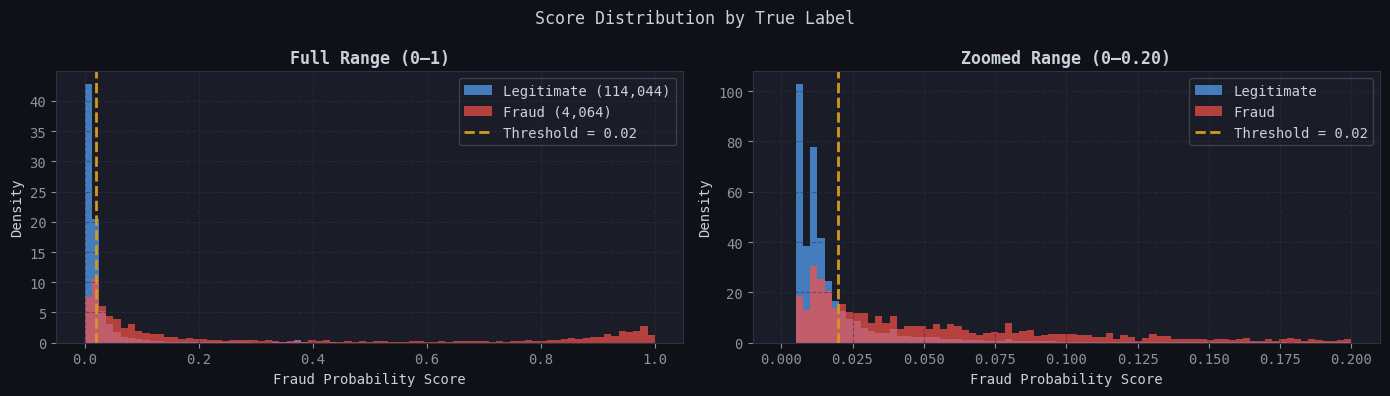

In [8]:
legit_proba = val_proba[y_val_arr == 0]
fraud_proba = val_proba[y_val_arr == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Score Distribution by True Label", fontsize=12)

bins = np.linspace(0, 1, 80)

# Full range
ax = axes[0]
ax.hist(legit_proba, bins=bins, color=ACCENT,  alpha=0.7, label=f"Legitimate ({len(legit_proba):,})", density=True)
ax.hist(fraud_proba, bins=bins, color=FRAUD,   alpha=0.7, label=f"Fraud ({len(fraud_proba):,})",      density=True)
ax.axvline(THRESHOLD, color=NEUTRAL, lw=2, ls="--", label=f"Threshold = {THRESHOLD}")
ax.set_xlabel("Fraud Probability Score")
ax.set_ylabel("Density")
ax.set_title("Full Range (0–1)")
ax.legend(framealpha=0.2)
ax.grid(True)

# Zoom on [0, 0.20]
ax = axes[1]
bins_zoom = np.linspace(0, 0.20, 80)
ax.hist(legit_proba, bins=bins_zoom, color=ACCENT,  alpha=0.7, label="Legitimate", density=True)
ax.hist(fraud_proba, bins=bins_zoom, color=FRAUD,   alpha=0.7, label="Fraud",      density=True)
ax.axvline(THRESHOLD, color=NEUTRAL, lw=2, ls="--", label=f"Threshold = {THRESHOLD}")
ax.set_xlabel("Fraud Probability Score")
ax.set_ylabel("Density")
ax.set_title("Zoomed Range (0–0.20)")
ax.legend(framealpha=0.2)
ax.grid(True)

plt.tight_layout()
plt.show()

---
## Section 6 — Business Impact Summary

This section translates model metrics into financial terms. The key question is: how much of the fraud loss can the model prevent, and at what operational cost?

All figures are on the temporal validation set.

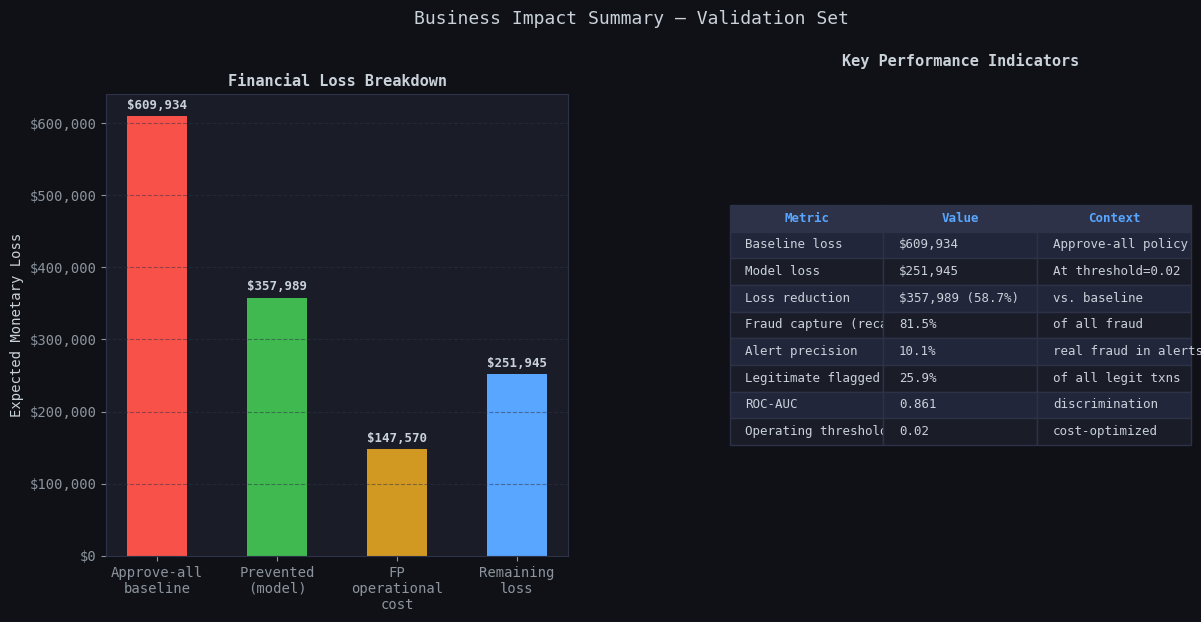


Bottom line: the model prevents $357,989 in fraud losses (58.7% of the baseline) at a threshold of 0.02.


In [9]:
baseline      = approve_all_baseline_loss(y_val_arr, val_amount.values)
model_loss    = expected_loss(y_val_arr, val_proba, val_amount.values, C_FP, THRESHOLD)
fn_loss       = expected_loss(y_val_arr, val_proba, val_amount.values, 0.0,  THRESHOLD)  # FN only
fp_cost       = model_loss - fn_loss                                                      # FP only
reduction     = baseline - model_loss
recall        = val_pred[y_val_arr == 1].mean()
precision_val = (val_pred[y_val_arr == 1].sum() / val_pred.sum()) if val_pred.sum() > 0 else 0
fpr_val       = val_pred[y_val_arr == 0].mean()

# ── Loss waterfall ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))
gs  = GridSpec(1, 2, figure=fig, wspace=0.35)

# Left: waterfall
ax1 = fig.add_subplot(gs[0])
categories = ["Approve-all\nbaseline", "Prevented\n(model)", "FP\noperational\ncost", "Remaining\nloss"]
values     = [baseline, -reduction, fp_cost, model_loss]
bar_cols   = [FRAUD, LEGIT, NEUTRAL, ACCENT]
bars = ax1.bar(categories, [baseline, reduction, fp_cost, model_loss],
               color=bar_cols, edgecolor="none", width=0.5)
for bar, val in zip(bars, [baseline, reduction, fp_cost, model_loss]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + baseline * 0.01,
             f"${val:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.set_title("Financial Loss Breakdown", fontsize=11)
ax1.set_ylabel("Expected Monetary Loss")
ax1.grid(True, axis="y")

# Right: KPI table
ax2 = fig.add_subplot(gs[1])
ax2.axis("off")
kpis = [
    ["Metric",                    "Value",                            "Context"],
    ["Baseline loss",             f"${baseline:,.0f}",                "Approve-all policy"],
    ["Model loss",                f"${model_loss:,.0f}",              "At threshold=0.02"],
    ["Loss reduction",            f"${reduction:,.0f} ({reduction/baseline*100:.1f}%)", "vs. baseline"],
    ["Fraud capture (recall)",    f"{recall:.1%}",                    "of all fraud"],
    ["Alert precision",           f"{precision_val:.1%}",             "real fraud in alerts"],
    ["Legitimate flagged (FPR)",  f"{fpr_val:.1%}",                   "of all legit txns"],
    ["ROC-AUC",                   f"{roc_auc_score(y_val_arr, val_proba):.3f}", "discrimination"],
    ["Operating threshold",       f"{THRESHOLD}",                     "cost-optimized"],
]
table = ax2.table(
    cellText=kpis[1:], colLabels=kpis[0],
    loc="center", cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2e3248")
        cell.set_text_props(color=ACCENT, fontweight="bold")
    else:
        cell.set_facecolor("#1a1d27" if row % 2 == 0 else "#22263a")
        cell.set_text_props(color="#c9d1d9")
    cell.set_edgecolor("#2e3248")
ax2.set_title("Key Performance Indicators", fontsize=11, pad=20)

fig.suptitle("Business Impact Summary — Validation Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nBottom line: the model prevents ${reduction:,.0f} in fraud losses"
      f" ({reduction/baseline*100:.1f}% of the baseline) at a threshold of {THRESHOLD}.")